**NOTE :** For a new MRI image, the model produces a probability between 0 and 1.
```
Probability ≥ 0.5 → Tumourous
Probability < 0.5 → Non-Tumourous
```

In [12]:
# import libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# define project paths

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project"
MODELS_DIR = os.path.join(PROJECT_DIR, "models")

BEST_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "best_brain_tumor_cnn.keras"
)

print("Project directory:", PROJECT_DIR)
print("Model path:", BEST_MODEL_PATH)
print("Model exists:", os.path.exists(BEST_MODEL_PATH))

Project directory: /content/drive/MyDrive/Brain_Tumor_CNN_Project
Model path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_brain_tumor_cnn.keras
Model exists: True


In [14]:
# load the trained CNN model

model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("Best CNN model loaded successfully.")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

Best CNN model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


In [15]:
# define the MRI image preprocessing function

IMG_SIZE = (224, 224)

def preprocess_single_image(image_path):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    image = tf.expand_dims(image, axis=0)

    return image

print("Image preprocessing function defined successfully.")

Image preprocessing function defined successfully.


Why ```expand_dims```?

The CNN expects input in the form : (batch_size, 224, 224, 3)

For one image, we therefore convert it into :(1, 224, 224, 3)

In [16]:
# upload a new MRI image

from google.colab import files

uploaded = files.upload()

print("Uploaded file(s):")
for filename in uploaded.keys():
    print("-", filename)

Saving brain tumor image 1.jfif to brain tumor image 1.jfif
Uploaded file(s):
- brain tumor image 1.jfif


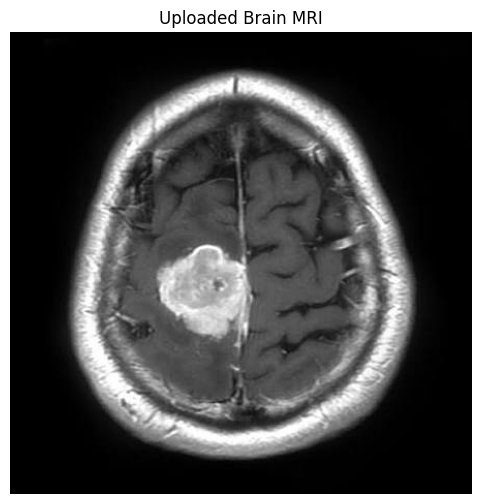

Image filename: brain tumor image 1.jfif
Original image size: (447, 447)
Image mode: RGB


In [17]:
# display the uploaded MRI image

image_filename = list(uploaded.keys())[0]

image = Image.open(image_filename)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Uploaded Brain MRI")
plt.axis("off")
plt.show()

print("Image filename:", image_filename)
print("Original image size:", image.size)
print("Image mode:", image.mode)

In [25]:
# pass the uploaded MRI through the same preprocessing pipeline and then let the trained CNN predict the probability of a tumour
# preprocess the uploaded MRI

processed_image = preprocess_single_image(image_filename)

print("Processed image shape:", processed_image.shape)
print("Pixel value range:",
      float(tf.reduce_min(processed_image)),
      "to",
      float(tf.reduce_max(processed_image)))

# Make prediction
prediction_probability = model.predict(
    processed_image,
    verbose=0
)[0][0]

print("Tumour probability:", prediction_probability)


# convert probability into the final prediction
THRESHOLD = 0.5

if prediction_probability >= THRESHOLD:
    prediction_label = "Tumour Detected"
    confidence = prediction_probability * 100
else:
    prediction_label = "No Tumour Detected"
    confidence = (1 - prediction_probability) * 100

print("\nPrediction:", prediction_label)
print(f"Confidence: {confidence:.2f}%")

Processed image shape: (1, 224, 224, 3)
Pixel value range: 0.0 to 1.0
Tumour probability: 0.87932265

Prediction: Tumour Detected
Confidence: 87.93%


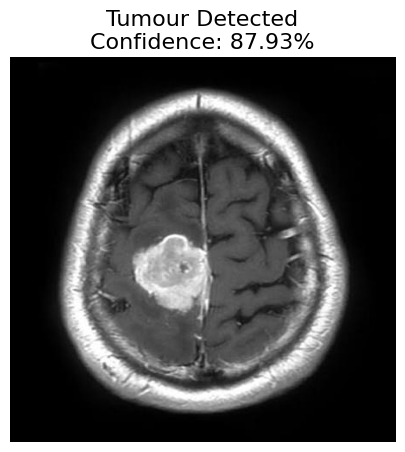

In [22]:
# display the MRI with the final prediction

plt.figure(figsize=(7, 5))

plt.imshow(image)
plt.title(
    f"{prediction_label}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=16
)

plt.axis("off")
plt.show()

In [26]:
# create a reusable prediction function

def predict_mri(image_path, threshold=0.5):
    # Preprocess image
    processed_image = preprocess_single_image(image_path)

    # Predict probability
    probability = model.predict(
        processed_image,
        verbose=0
    )[0][0]

    # Apply classification threshold
    if probability >= threshold:
        label = "Tumour Detected"
        confidence = probability * 100
    else:
        label = "No Tumour Detected"
        confidence = (1 - probability) * 100

    return label, confidence, probability


# test the function
label, confidence, probability = predict_mri(image_filename)

print("MRI Prediction Result")
print("---------------------")
print("Prediction :", label)
print(f"Confidence : {confidence:.2f}%")
print(f"Probability: {probability:.4f}")

MRI Prediction Result
---------------------
Prediction : Tumour Detected
Confidence : 87.93%
Probability: 0.8793


Saving brain tumor image 1.jfif to brain tumor image 1 (3).jfif
Saving brain tumor image 2.jfif to brain tumor image 2 (2).jfif
Saving brain tumor image 3.jfif to brain tumor image 3 (2).jfif
Saving brain tumor image 4.jfif to brain tumor image 4 (2).jfif
Saving brain tumor image 5.jfif to brain tumor image 5 (2).jfif

Prediction Results

Image: brain tumor image 1 (3).jfif
Prediction : Tumour Detected
Confidence : 87.93%
Probability: 0.8793


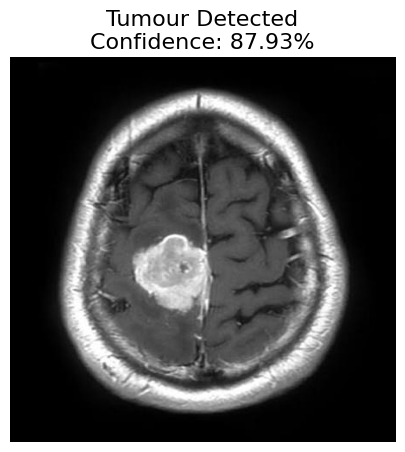


Image: brain tumor image 2 (2).jfif
Prediction : Tumour Detected
Confidence : 98.17%
Probability: 0.9817


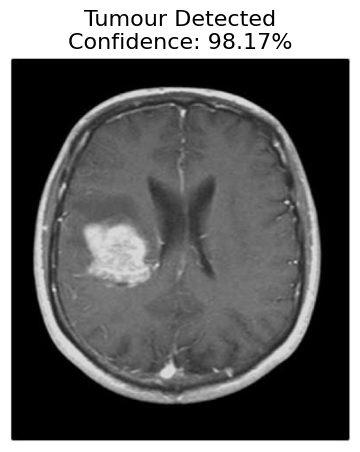


Image: brain tumor image 3 (2).jfif
Prediction : No Tumour Detected
Confidence : 99.93%
Probability: 0.0007


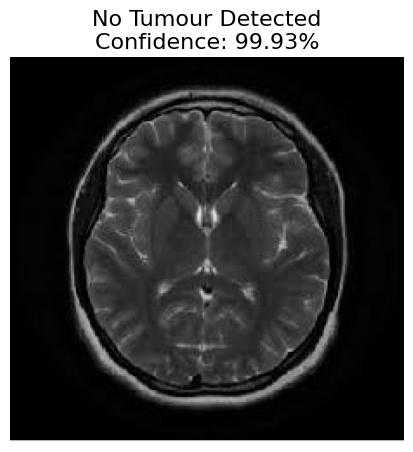


Image: brain tumor image 4 (2).jfif
Prediction : No Tumour Detected
Confidence : 88.63%
Probability: 0.1137


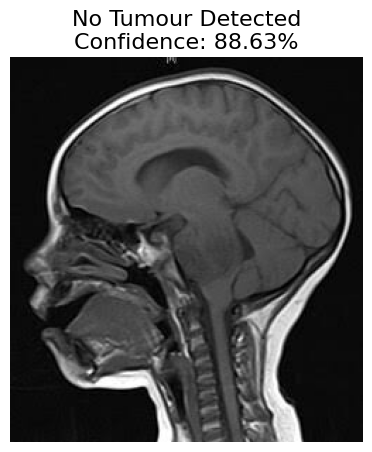


Image: brain tumor image 5 (2).jfif
Prediction : No Tumour Detected
Confidence : 80.11%
Probability: 0.1989


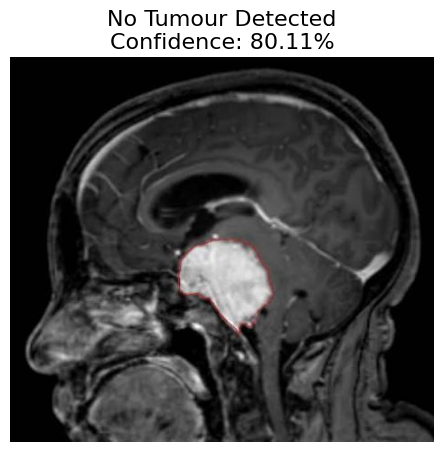

In [29]:
# test multiple MRI images and display predictions

from google.colab import files

uploaded_multiple = files.upload()

print("\nPrediction Results")
print("==================")

for filename in uploaded_multiple.keys():

    # Make prediction
    label, confidence, probability = predict_mri(filename)

    # Display result in text
    print(f"\nImage: {filename}")
    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.2f}%")
    print(f"Probability: {probability:.4f}")

    # Open image
    image = Image.open(filename)

    # Display image
    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.title(
        f"{label}\n"
        f"Confidence: {confidence:.2f}%",
        fontsize=16
    )
    plt.axis("off")
    plt.show()